In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import numpy as np
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
chars = []
for i in range(ord('a'), ord('z') + 1):
    print(chr(i), end=' ')
    chars.append(f"{chr(i)}")
stoi={}
stoi['.'] = 0
stoi|= {ch: i+1  for i, ch in enumerate(chars)}
itos = {i:ch for (ch, i) in stoi.items()}

a b c d e f g h i j k l m n o p q r s t u v w x y z 

In [5]:
# build the dataset
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 3

def build_dataset(words):
    # Rolling window dataset: 
    context = [stoi['.']] *  block_size
    X, Y  = [], []
    
    for w in words[:]:
        chrs = list(w) + ['.']
        for ch in chrs:
            #print(context, ch)
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]
    # for x, y in zip(X, Y):
    #     print(''.join([itos[k] for k in x]), itos[y])
    
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    print(Xt.shape, Yt.shape)
    return Xt, Yt

# random shuffle
import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtrain, Ytrain = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182706, 3]) torch.Size([182706])
torch.Size([22800, 3]) torch.Size([22800])
torch.Size([22640, 3]) torch.Size([22640])


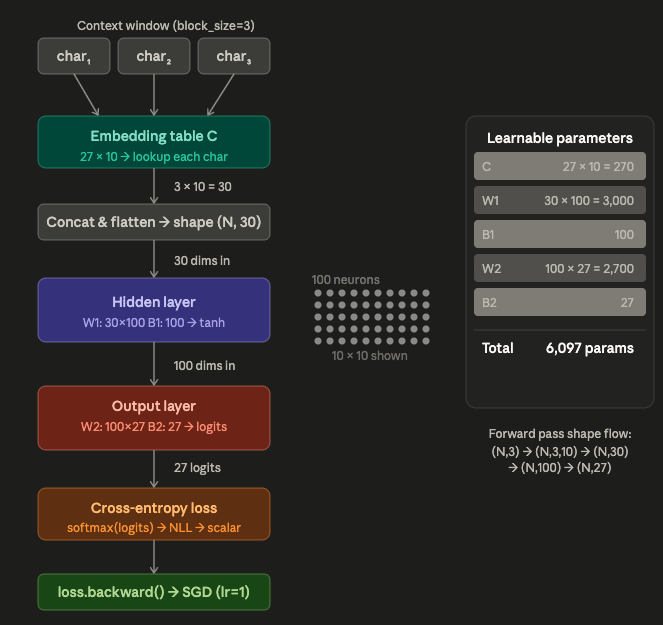

In [6]:
embed_dim = 10
vocab_size = 27
context_len = 3
num_hidden = 100 # 100 neurons in the hidden layer.

# generator
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, embed_dim), generator=g)

total_context_len = embed_dim * context_len

# hidden layer 1
W1 = torch.randn((total_context_len, num_hidden), generator = g) * (total_context_len ** -0.5)
B1 = torch.randn(num_hidden, generator = g) * 0.1

# BN layer

bngamma = torch.randn(num_hidden, generator = g) * 0.1
bnbeta = torch.randn(num_hidden, generator = g) * 0.1

# output layer
W2 = torch.randn((num_hidden, vocab_size), generator = g) * 0.1
B2 = torch.randn(vocab_size, generator = g) * 0.1

parameters = [C, W1, B1, bngamma, bnbeta, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True


6297


In [7]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

 W1 = ((tensor(0.0039, grad_fn=<MeanBackward0>), tensor(0.1871, grad_fn=<StdBackward0>))), W2 = ((tensor(-0.0019, grad_fn=<MeanBackward0>), tensor(0.1020, grad_fn=<StdBackward0>)))


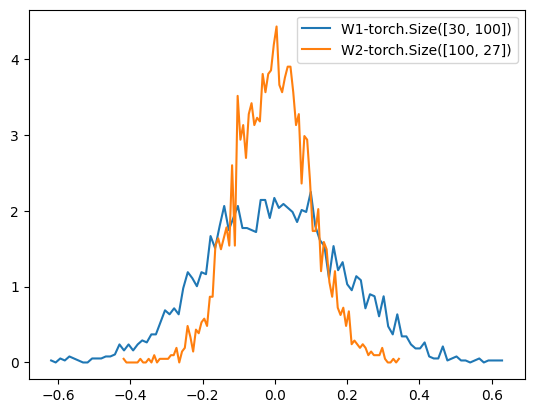

In [8]:
#%history -g
t = W1
legends=[]
def add_plot(t, legend):
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f"{legend}-{t.shape}")

add_plot(W1, "W1")
add_plot(W2, "W2")
#add_plot(bngamma, "gamma")
#add_plot(bnbeta, "beta")
plt.legend(legends)
print(f" W1 = ({W1.mean(), W1.std()}), W2 = ({W2.mean(), W2.std()})")

In [9]:
# Create a single batch for forward pass work

batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtrain.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtrain[ix], Ytrain[ix] # batch X,Y

In [10]:
# forward pass

emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

hprebn = embcat @ W1 + B1 # hidden layer preactivation.

# batch normalization
bnmeani = hprebn.sum(0, keepdim=True) / hprebn.shape[0]
bndiff = hprebn - bnmeani

bndiff2 = bndiff ** 2
bnvar = bndiff2.sum(0, keepdim=True) * (1/(n-1))
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = bndiff * bnvar_inv

hpreact = bngamma * bnraw + bnbeta

# tanh activation
h = torch.tanh(hpreact)

# linear layer 2

logits = h @ W2 + B2
logit_maxes = logits.max(1, keepdims=True).values

# softmax cross entropy
norm_logits = logits - logit_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum ** -1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()



# PyTorch backward pass
for p in parameters:
  p.grad = None
    
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.2594, grad_fn=<NegBackward0>)

In [11]:
logprobs.shape

torch.Size([32, 27])

In [12]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one
dlogprobs = torch.zeros_like(logprobs)
for x,y in zip(range(n), Yb):
    dlogprobs[x, y] = -1.0/n
cmp('logprobs', dlogprobs, logprobs)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [14]:
counts_sum_inv.shape

torch.Size([32, 1])

In [15]:
dprobs = dlogprobs * (probs ** -1)
cmp('probs', dprobs, probs)

dcounts_sum_inv = (dprobs * counts).sum(1, keepdims=True)
# dcounts_sum_inv = torch.zeros_like(counts_sum_inv)
# for i in range(dcounts_sum_inv.shape[0]):
#     dcounts_sum_inv[i,0] = temp.sum(1, keep_dims=true) 
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [16]:
norm_logits.shape, logits.max(1, keepdims=True).indices

(torch.Size([32, 27]),
 tensor([[10],
         [16],
         [11],
         [10],
         [21],
         [10],
         [16],
         [26],
         [10],
         [16],
         [16],
         [10],
         [16],
         [21],
         [16],
         [16],
         [16],
         [16],
         [16],
         [10],
         [21],
         [16],
         [21],
         [16],
         [21],
         [16],
         [21],
         [10],
         [16],
         [10],
         [10],
         [21]]))

In [17]:
dcounts_sum = -dcounts_sum_inv * (counts_sum ** -2)
cmp('counts_sum', dcounts_sum, counts_sum)

dcounts = dcounts_sum.repeat((1, counts.shape[1])) + dprobs * counts_sum_inv

cmp('counts', dcounts, counts)

dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

#dlogit_maxes= - dnorm_logits.gather(dim = 1, index=logits.max(1, keepdims=True).indices)
dlogit_maxes = -dnorm_logits.sum(1, keepdims=True)
cmp('logit_maxes', dlogit_maxes, logit_maxes)

max_indices = logits.max(1, keepdims=True).indices
dlogits = dnorm_logits.clone().detach()

for i in range(logits.shape[0]):
    j = max_indices[i, 0]
    dlogits[i, j] -= dnorm_logits[i].sum()
    #print(dnorm_logits[i], dnorm_logits[i].sum())
    #dlogits[i, j] += dnorm_logits[i, j]

cmp('logits', dlogits, logits)






counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

dB2 = dlogits.sum(0)
cmp('b2', dB2, B2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


In [19]:
# hpreact = bngamma * bnraw + bnbeta
# h = torch.tanh(hpreact)

dhpreact = (1 - h**2) * dh

cmp('hpreact', dhpreact, hpreact)

dbngamma = (dhpreact * bnraw).sum(0)
cmp('bngain', dbngamma, bngamma)

dbnbeta = dhpreact.sum(0)
cmp('bnbeta', dbnbeta, bnbeta)

# bnmeani = hprebn.sum(0, keepdim=True) / hprebn.shape[0]
# bndiff = hprebn - bnmeani

# bndiff2 = bndiff ** 2
# bnvar = bndiff2.sum(0, keepdim=True) * (1/(n-1))
# bnvar_inv = (bnvar + 1e-5) ** -0.5
# bnraw = bndiff * bnvar_inv

dbnraw = dhpreact * bngamma
cmp('bnraw', dbnraw, bnraw)

dbnvar_inv = (dbnraw * bndiff).sum(0)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

dbnvar = (-0.5) * ((bnvar + 1e-5) ** (-1.5)) * dbnvar_inv
cmp('bnvar', dbnvar, bnvar)

dbndiff2 = dbnvar.expand(bndiff.shape) * (1/(n-1))
cmp('bndiff2', dbndiff2, bndiff2)

dbndiff = dbndiff2 * (2 * bndiff) + dbnraw * bnvar_inv
cmp('bndiff', dbndiff, bndiff)

dbnmeani = -dbndiff.sum(0)
cmp('bnmeani', dbnmeani, bnmeani)

dhprebn = dbndiff + dbnmeani / hprebn.shape[0]
cmp('hprebn', dhprebn, hprebn)



hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbeta          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0
bnvar           | exact: True  | approximate: True  | maxdiff: 0.0
bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0
bndiff          | exact: True  | approximate: True  | maxdiff: 0.0
bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0
hprebn          | exact: True  | approximate: True  | maxdiff: 0.0


In [20]:
# emb = C[Xb]
# embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

# hprebn = embcat @ W1 + B1 # hidden layer preactivation.

dembcat = dhprebn @ W1.T

cmp('embcat', dembcat, embcat)

dW1 = embcat.T @ dhprebn

cmp('W1', dW1, W1)

dB1 = dhprebn.sum(0)

cmp('b1', dB1, B1)

demb = dembcat.view(emb.shape)
cmp('emb', demb, emb)


embcat          | exact: True  | approximate: True  | maxdiff: 0.0
W1              | exact: True  | approximate: True  | maxdiff: 0.0
b1              | exact: True  | approximate: True  | maxdiff: 0.0
emb             | exact: True  | approximate: True  | maxdiff: 0.0


In [21]:
C.shape, emb.shape, Xb.shape
dC = torch.zeros_like(C)

for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ich = Xb[i, j].item()
        gradients = demb[i, j]
        
        dC[ich] += gradients
  

cmp('C', dC, C)  

C               | exact: True  | approximate: True  | maxdiff: 0.0


In [22]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.259371280670166 diff: 0.0


In [23]:
dlogits = F.softmax(logits, dim=1)
n = Yb.shape[0]
dlogits[range(n), Yb] -=1
dlogits /= n

In [24]:
cmp('logits', dlogits, logits), n

logits          | exact: False | approximate: True  | maxdiff: 7.2177499532699585e-09


(None, 32)

In [25]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngamma * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbeta
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(8.9407e-08, grad_fn=<MaxBackward1>)


In [26]:
hprebn.shape, hpreact_fast.shape,  torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5).shape

(torch.Size([32, 100]), torch.Size([32, 100]), torch.Size([1, 100]))

In [27]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
dhprebn = None # TODO. my solution is 1 (long) line
# -----------------
#dhprebn = bngamma * 

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

SyntaxError: invalid syntax (3963825530.py, line 21)

In [ ]:
F.softmax(logits, 1)[0]

In [ ]:
dlogits[0]

In [ ]:
plt.imshow(dlogits.detach(), cmap='gray')

In [28]:
bnmeani.shape

torch.Size([1, 100])

In [ ]:
# finally putting together forward pass with the shortened computations
# forward pass

emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

hprebn = embcat @ W1 + B1 # hidden layer preactivation.

# batch normalization
# bnmeani = hprebn.sum(0, keepdim=True) / hprebn.shape[0]
# bndiff = hprebn - bnmeani

# bndiff2 = bndiff ** 2
# bnvar = bndiff2.sum(0, keepdim=True) * (1/(n-1))
# bnvar_inv = (bnvar + 1e-5) ** -0.5
# bnraw = bndiff * bnvar_inv

# hpreact = bngamma * bnraw + bnbeta

hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

# tanh activation
h = torch.tanh(hpreact_fast)

# linear layer 2

logits = h @ W2 + B2
# logit_maxes = logits.max(1, keepdims=True).values

# softmax cross entropy
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum ** -1
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())



# PyTorch backward pass
for p in parameters:
  p.grad = None
    
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss_fast.backward()
loss_fast

In [ ]:
# backward pass manually but for the shorter version:

dlogits = F.softmax(logits, dim=1)
n = Yb.shape[0]
dlogits[range(n), Yb] -=1
dlogits /= n

# backprop through the final layer
dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

dB2 = dlogits.sum(0)
cmp('b2', dB2, B2)

#hidden pre act
dhpreact = (1 - h**2) * dh

cmp('hpreact', dhpreact, hpreact)

# backprop through batch norm layer.



In [ ]:
# TODO: 
# Calibrate the batch norm at the end of the training over the entire training set.
# Biased vs unbiaed bessel's correction. 

with torch.no_grad():
    emb = C[Xtrain]
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

    hprebn = embcat @ W1 + B1 # hidden layer preactivation.
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    